In [1]:
import pandas as pd
from sqlalchemy import create_engine
import urllib.parse
from create_engine import ENGINE

query = """
SELECT *
FROM IDS_DATA_AFTER_PREPROCESSING
"""

df = pd.read_sql(query, ENGINE)

print(df.head())

2026-08-22 22:03:52,302 - INFO - Connection Built Successfully


Connecting to DB: localhost/cti_fyp_2
   protocol  flow duration  total fwd packet  total bwd packets  \
0        17             56                 2                  2   
1        17          90721                 1                  1   
2        17          24959                 2                  2   
3        17            138                 2                  2   
4        17          30487                 4                  2   

   total length of fwd packet  total length of bwd packet  \
0                        78.0                       358.0   
1                        48.0                       149.0   
2                        84.0                       362.0   
3                        62.0                        94.0   
4                       148.0                       106.0   

   fwd packet length max  fwd packet length min  fwd packet length mean  \
0                   39.0                   39.0                    39.0   
1                   48.0                  

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import joblib

In [4]:
model_load = joblib.load('preprocessed_encoder.joblib')

In [5]:
print(dict(enumerate(model_load.classes_))) 

{0: 'BENIGN', 1: 'Bot', 2: 'DDoS', 3: 'DoS GoldenEye', 4: 'DoS Hulk', 5: 'DoS Slowhttptest', 6: 'DoS slowloris', 7: 'FTP-Patator', 8: 'Heartbleed', 9: 'Infiltration', 10: 'PortScan', 11: 'SSH-Patator', 12: 'Web Attack - Brute Force', 13: 'Web Attack - Sql Injection', 14: 'Web Attack - XSS'}


C:\Users\UMAR.TECH\AppData\Local\Temp\ipykernel_8008\3953788656.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='flare')


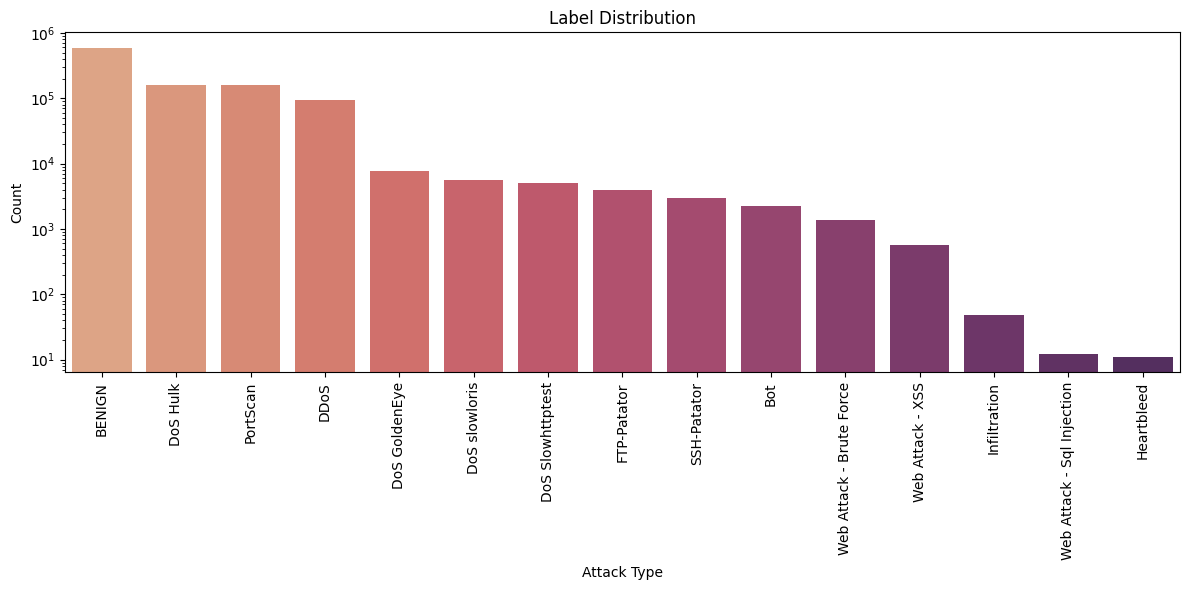

In [6]:
plt.figure(figsize=(12,6))
df['label_name'] = model_load.inverse_transform(df['label'])
label_counts = df['label_name'].value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values, palette='flare')
plt.xticks(rotation=90)
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.yscale('log')
plt.title('Label Distribution')
plt.tight_layout()
plt.show()

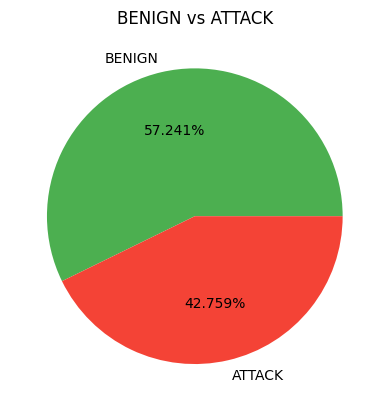

In [19]:
benign = (df['label'] == 0).sum()
attack = (df['label'] != 0).sum()

plt.pie(
    [benign, attack],
    labels=['BENIGN', 'ATTACK'],
    autopct='%1.3f%%',
    colors=['#4CAF50', '#F44336']
)
plt.title('BENIGN vs ATTACK')
plt.show()

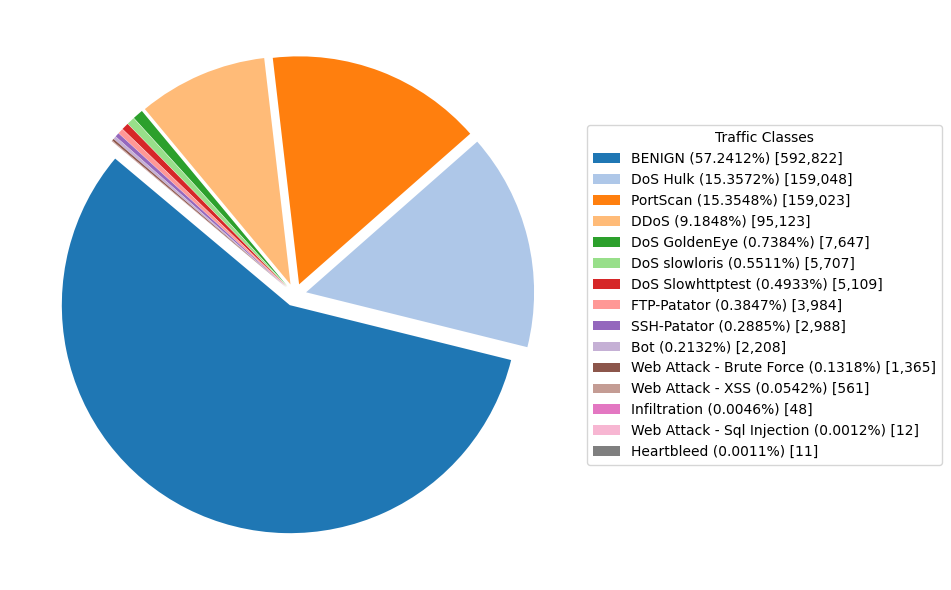

In [17]:
df['label_name'] = model_load.inverse_transform(df['label'].astype(int))
label_counts = df['label_name'].value_counts()  
counts = df['label_name'].value_counts()         
percentages = df['label_name'].value_counts(normalize=True) * 100  

plt.figure(figsize=(12, 6))
colors = sns.color_palette('tab20', len(counts))
explode = [0.05] * len(counts)

wedges, _ = plt.pie(
    counts, 
    labels=None,       
    startangle=140, 
    colors=colors, 
    explode=explode
)

legend_labels = [
    f'{label} ({pct:.4f}%) [{count:,}]' 
    for label, pct, count in zip(counts.index, percentages, counts.values)
]

plt.legend(
    wedges, 
    legend_labels, 
    title="Traffic Classes", 
    loc="center left", 
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

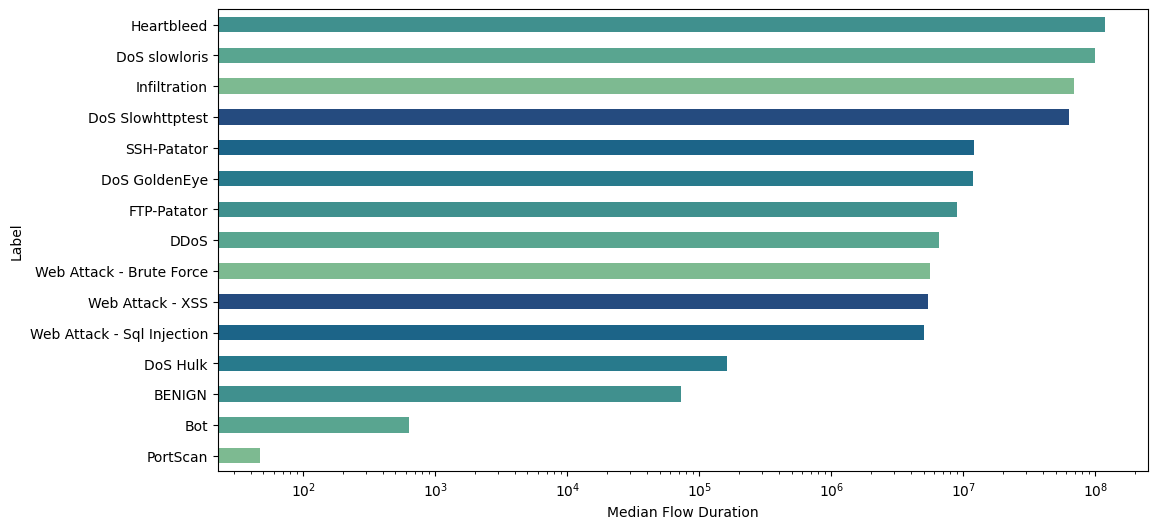

In [9]:
df['label_name'] = model_load.inverse_transform(df['label'])
label_counts = df['label_name'].value_counts()
plt.figure(figsize=(12,6))
df.groupby('label_name')['flow duration'].median().sort_values().plot(kind='barh',color= sns.color_palette('crest'))  # ← groupby label_name directly
plt.xlabel('Median Flow Duration')
plt.ylabel('Label')
plt.xscale('log')
plt.show()

C:\Users\UMAR.TECH\AppData\Local\Temp\ipykernel_8008\1185112302.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='label_name', y='down/up ratio', order=order, palette='mako')


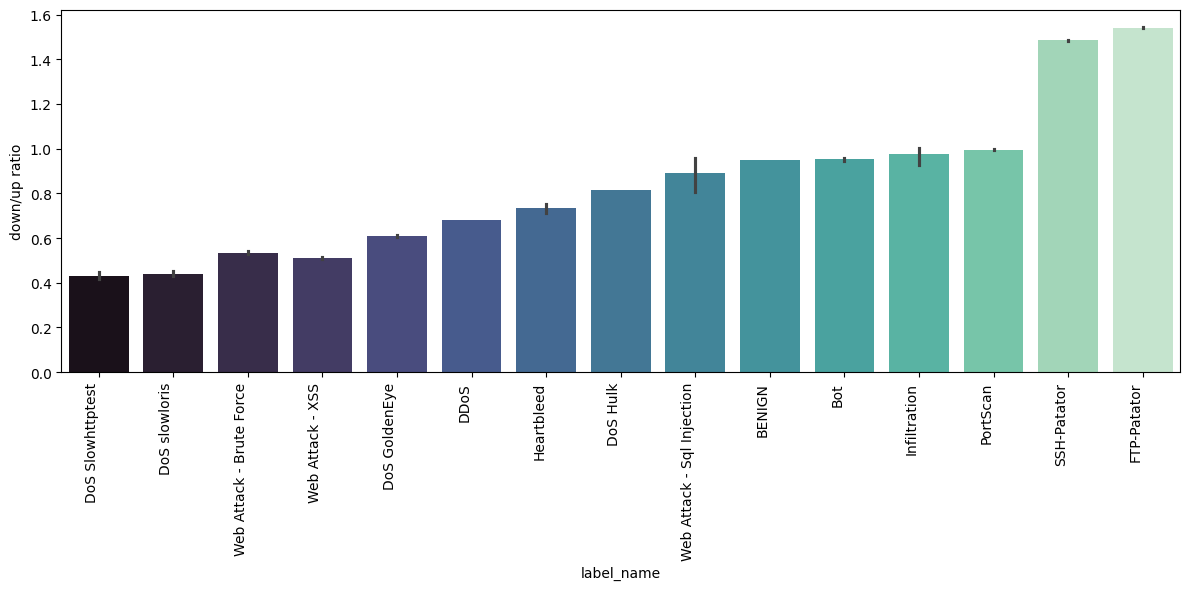

In [10]:
df['label_name'] = model_load.inverse_transform(df['label'])
label_counts = df['label_name'].value_counts()
plt.figure(figsize=(12,6))
order = df.groupby('label_name')['down/up ratio'].median().sort_values().index
sns.barplot(data=df, x='label_name', y='down/up ratio', order=order, palette='mako') 
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

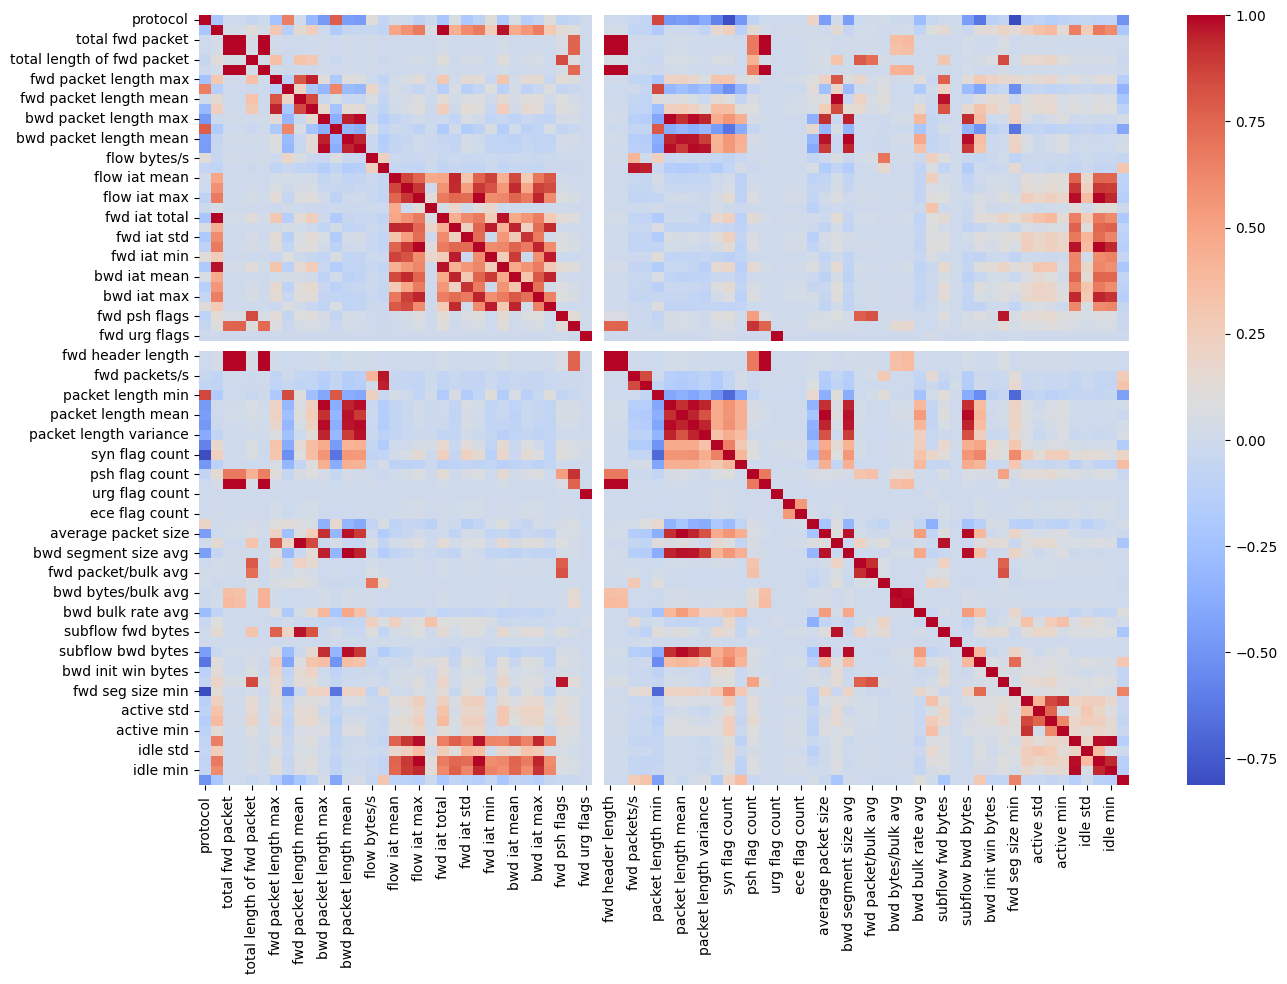

In [11]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

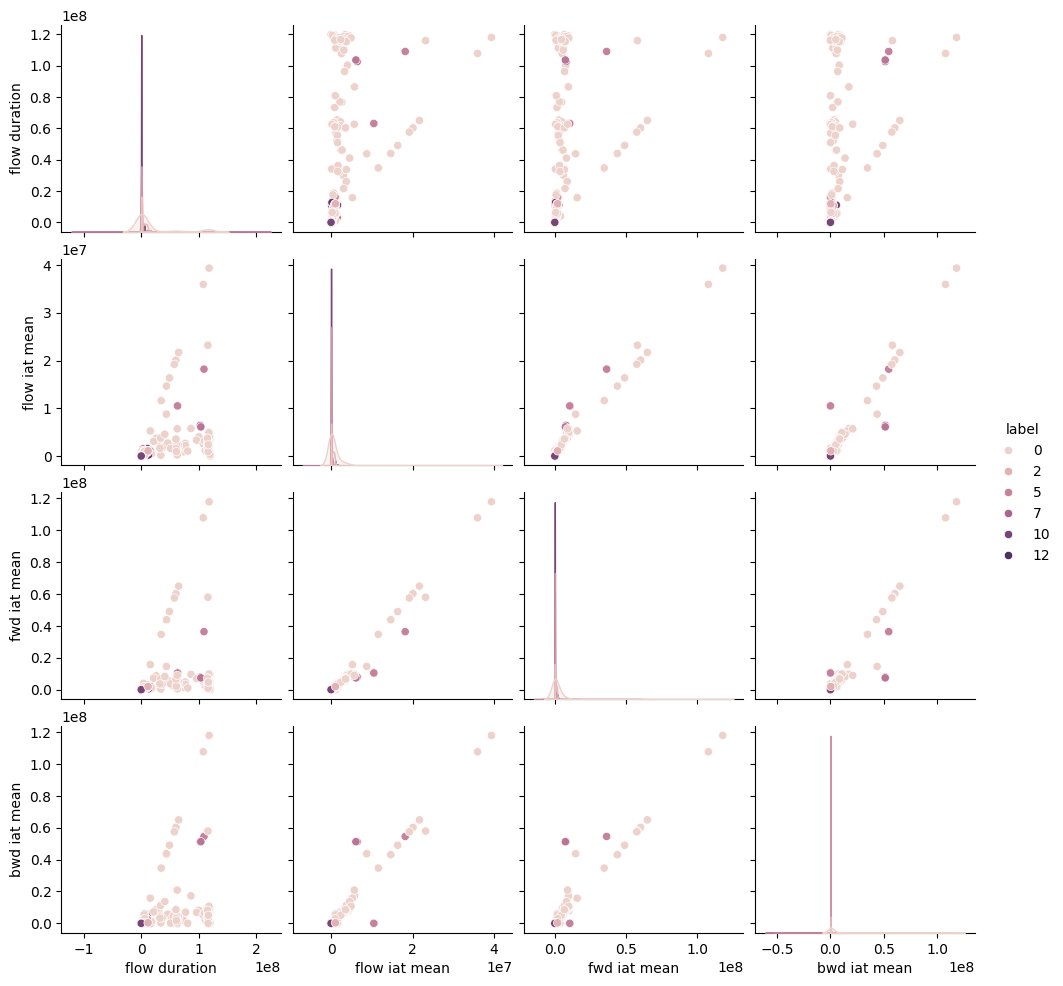

In [12]:
time_features = ['flow duration', 'flow iat mean', 'fwd iat mean', 'bwd iat mean', 'label']
sns.pairplot(df.sample(1000, random_state=42)[time_features], hue='label');

c:\Users\UMAR.TECH\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\UMAR.TECH\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\UMAR.TECH\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\UMAR.TECH\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\UMAR.TECH\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` 

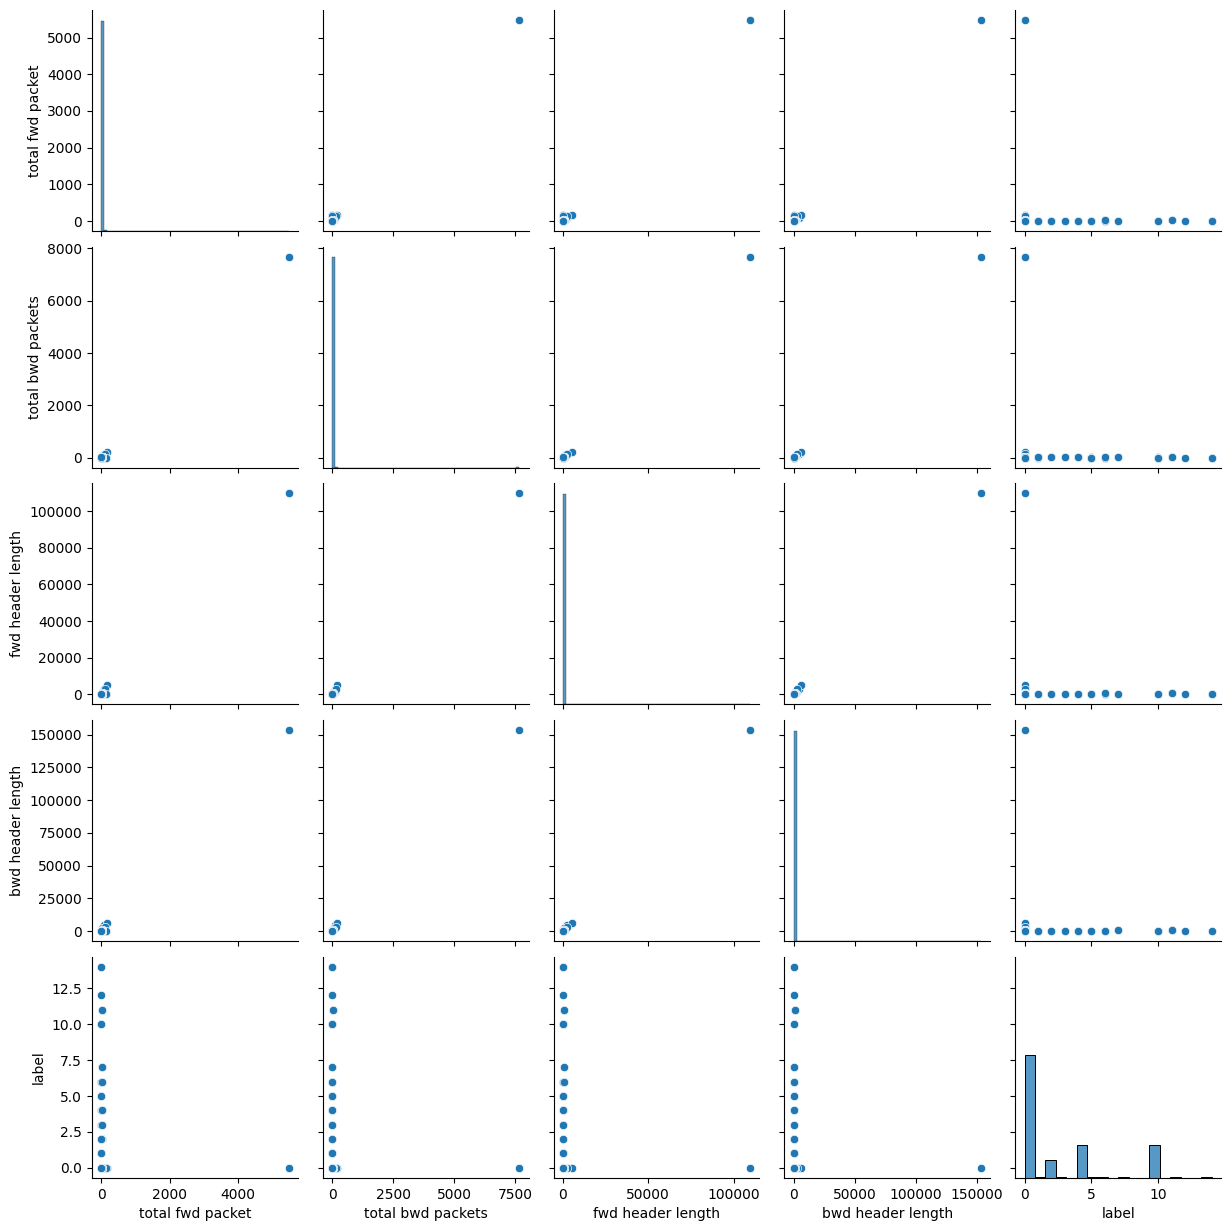

In [13]:
volume_features = ['total fwd packet', 'total bwd packets', 'fwd header length', 'bwd header length', 'label']
sns.pairplot(df.sample(1000, random_state=42)[volume_features], palette='Set1');

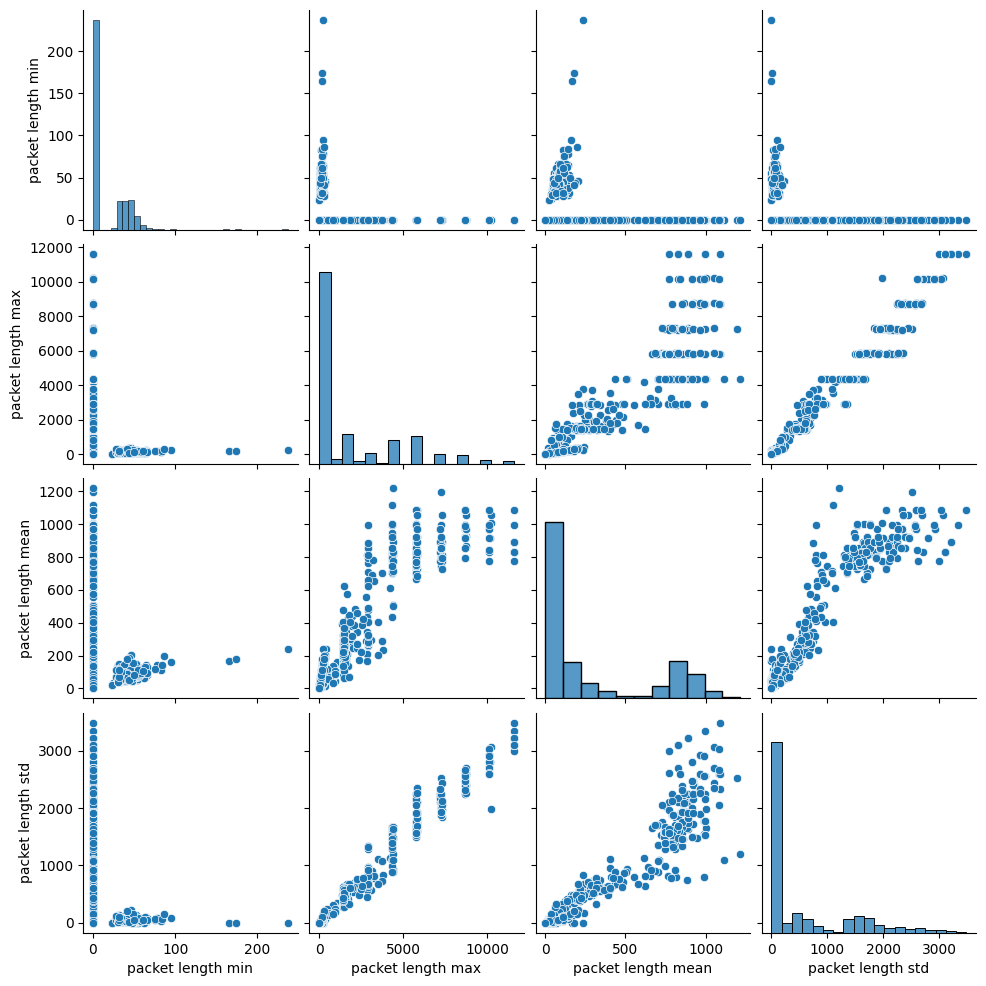

In [14]:
packet_cols = ['packet length min', 'packet length max', 'packet length mean', 'packet length std']
sns.pairplot(df.sample(1000, random_state=42)[packet_cols]);